<a href="https://colab.research.google.com/github/pedroyoshikadogarcia/Checkpoint-01-An-lise-de-Dados-de-Energia-SERS-02-2026/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
# 1
dados = pd.DataFrame(registros)

In [7]:
# 2
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [8]:
# 3
print(f'Número de registros: {dados.shape[0]}')
print(f'Número de atributos: {dados.shape[1]}')

Número de registros: 336
Número de atributos: 11


In [9]:
# 4
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [10]:
# 5
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [11]:
# 6
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


**Identificação dos atributos:**
- Data/hora: `din_referenciautc` (instante da medição, a cada 30 min) `dat_referencia` traz só a data
- Área de carga: `cod_areacarga` (neste caso, sempre "SP")
- Valor de carga: `val_cargaglobal` (carga global verificada, em MW médios)

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [12]:
# 1 - 2
dados = dados.rename(columns={
    'din_referenciautc': 'data_hora',
    'val_cargaglobal': 'carga_mw'
})

dados = dados[['data_hora', 'cod_areacarga', 'carga_mw']]
dados.head()

,data_hora,cod_areacarga,carga_mw
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488


In [13]:
# 3 - 4

dados.isnull().sum()

,0
data_hora,0
cod_areacarga,0
carga_mw,0


In [14]:
# 5
dados['carga_mw'].dtype

dtype('float64')

In [15]:
# 6
dados['data_hora'] = pd.to_datetime(dados['data_hora'])
dados['data_hora'].dtype

datetime64[ns, UTC]

**Decisões de tratamento:** não pussi valores ausentes na coluna `carga_mw` (confirmado pelo `isnull().sum()`). A coluna `data_hora` veio como texto (string) no formato ISO e foi convertida para `datetime` com `pd.to_datetime()` para permitir ordenação e análise.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [16]:
carga_min = dados['carga_mw'].min()
carga_max = dados['carga_mw'].max()
carga_media = dados['carga_mw'].mean()
carga_mediana = dados['carga_mw'].median()
amplitude = carga_max - carga_min
qtd_medicoes = len(dados)

print(f'Carga mínima: {carga_min:.2f} MW')
print(f'Carga máxima: {carga_max:.2f} MW')
print(f'Carga média: {carga_media:.2f} MW')
print(f'Mediana: {carga_mediana:.2f} MW')
print(f'Amplitude: {amplitude:.2f} MW')
print(f'Quantidade total de medições: {qtd_medicoes}')

Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Amplitude: 11046.06 MW
Quantidade total de medições: 336


**O valor máximo está muito distante do comportamento médio observado?**

O máximo (23185.31 MW) fica 5314.48 MW acima da média (17870.83 MW), uma diferença que representa cerca de 48% da amplitude total (11046.06 MW). Como a mediana (18199.13 MW) é próxima da média, a maior parte das medições fica concentrada numa faixa moderada, e o pico de 23185.31 MW representa um valor bem acima do comportamento típico da carga no período analisado.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [17]:
# 1
limiar_90 = 0.90 * carga_max
print(f'Limiar de alta demanda (90% do máximo): {limiar_90:.2f} MW')

Limiar de alta demanda (90% do máximo): 20866.78 MW


In [18]:
# 2 - 3
df_alta_demanda = dados[dados['carga_mw'] > limiar_90]
qtd_alta_demanda = len(df_alta_demanda)
print(f'Registros de alta demanda: {qtd_alta_demanda}')

Registros de alta demanda: 50


In [19]:
# 4
percentual_alta_demanda = (qtd_alta_demanda / qtd_medicoes) * 100
print(f'Percentual de alta demanda: {percentual_alta_demanda:.2f}%')

Percentual de alta demanda: 14.88%


In [20]:
# 5 - 6
pico_valor = dados['carga_mw'].max()
pico_momento = dados.loc[dados['carga_mw'].idxmax(), 'data_hora']
print(f'Pico de carga: {pico_valor:.2f} MW')
print(f'Momento do pico: {pico_momento}')

Pico de carga: 23185.31 MW
Momento do pico: 2025-08-01 22:00:00+00:00


**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

Os períodos de alta demanda (carga acima de 20866.78 MW) representam 50 dos 336 registros analisados, ou seja, 14.88% do período uma parcela pequena, concentrada em poucos momentos da semana. O pico absoluto (23185.31 MW) ocorreu em 01/08/2025 às 22:00 (horário UTC), o que é coerente com o horário de ponta do consumo residencial/comercial no fim da noite.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [21]:
# Critério escolhido: carga baixa (abaixo de 80% do máximo)
limiar_80 = 0.80 * carga_max
df_carga_baixa = dados[dados['carga_mw'] < limiar_80]

qtd_carga_baixa = len(df_carga_baixa)
percentual_carga_baixa = (qtd_carga_baixa / qtd_medicoes) * 100

print(f'Critério: carga abaixo de 80% do máximo ({limiar_80:.2f} MW)')
print(f'Registros: {qtd_carga_baixa}')
print(f'Percentual: {percentual_carga_baixa:.2f}%')

Critério: carga abaixo de 80% do máximo (18548.25 MW)
Registros: 172
Percentual: 51.19%


**Comparação com o conjunto de alta demanda:**

O critério de carga baixa (abaixo de 18548.25 MW) capturou 172 registros (51.19% do período), mais de 3x o volume do conjunto de alta demanda (50 registros, 14.88%). Isso confirma que a semana analisada passa a maior parte do tempo em patamares moderados a baixos de consumo, e os momentos de demanda elevada são exceção, não regra.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

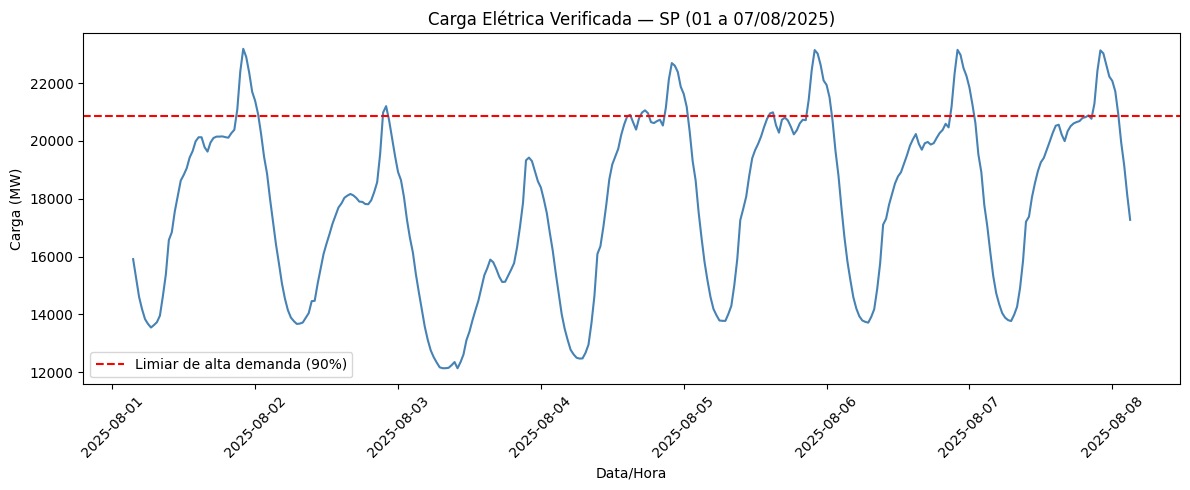

In [22]:
# Gráfico 1: comportamento da carga ao longo do tempo
plt.figure(figsize=(12, 5))
plt.plot(dados['data_hora'], dados['carga_mw'], color='steelblue')
plt.axhline(y=limiar_90, color='red', linestyle='--', label='Limiar de alta demanda (90%)')
plt.title('Carga Elétrica Verificada — SP (01 a 07/08/2025)')
plt.xlabel('Data/Hora')
plt.ylabel('Carga (MW)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico mostra o padrão típico de consumo elétrico ao longo dos dias: picos recorrentes no fim da noite (por volta das 22h) e vales durante a madrugada, com o limiar de alta demanda (linha vermelha) sendo ultrapassado apenas nos horários de maior consumo de cada dia.

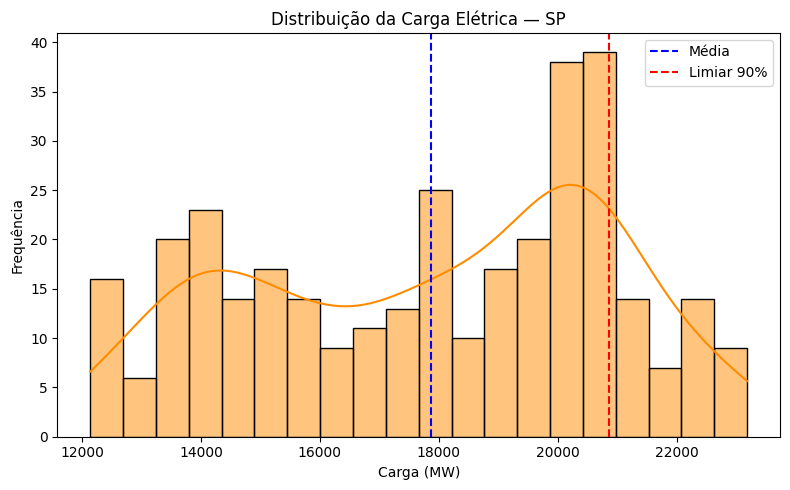

In [23]:
# Gráfico 2: distribuição dos valores de carga
plt.figure(figsize=(8, 5))
sns.histplot(dados['carga_mw'], bins=20, kde=True, color='darkorange')
plt.axvline(x=carga_media, color='blue', linestyle='--', label='Média')
plt.axvline(x=limiar_90, color='red', linestyle='--', label='Limiar 90%')
plt.title('Distribuição da Carga Elétrica — SP')
plt.xlabel('Carga (MW)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

A distribuição mostra que a maior concentração de registros fica entre a carga mínima e a média, com uma cauda mais curta em direção aos valores altos,reforçando que os 50 registros de alta demanda (14.88%) são de fato uma minoria dentro da distribuição geral.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [24]:
resumo_resultados = f'''
Região analisada: {dados['cod_areacarga'].iloc[0]}
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {qtd_medicoes}
Carga mínima: {carga_min:.2f} MW
Carga máxima: {carga_max:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Limiar de alta demanda (90% do máximo): {limiar_90:.2f} MW
Registros de alta demanda: {qtd_alta_demanda} ({percentual_alta_demanda:.2f}%)
Momento do pico: {pico_momento}
Segundo critério (carga abaixo de 80% do máximo): {qtd_carga_baixa} registros ({percentual_carga_baixa:.2f}%)
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90% do máximo): 20866.78 MW
Registros de alta demanda: 50 (14.88%)
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (carga abaixo de 80% do máximo): 172 registros (51.19%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [29]:
!pip -q install -U google-genai

In [30]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [31]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [32]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico: Análise de Carga Elétrica – Região SP

**Período de Análise:** 01/08/2025 a 07/08/2025  
**Elaborado por:** Analista de Dados do Setor Elétrico  

---

### 1. Caracterização do Conjunto Analisado
O conjunto de dados compreende medições do sistema elétrico da **Região SP** coletadas durante o período de **01/08/2025 a 07/08/2025**. A base auditada contém um total de **336 registros** válidos.

---

### 2. Principais Indicadores
Os dados observados no período apresentam os seguintes parâmetros operacionais de carga (medidos em Megawatts - MW):

*   **Carga Mínima:** 12.139,25 MW
*   **Carga Média:** 17.870,83 MW
*   **Mediana:** 18.199,13 MW
*   **Carga Máxima (Pico):** 23.185,31 MW (registrada em **01/08/2025 às 22:00:00+00:00**)

*Observação dos dados:* A mediana (18.199,13 MW) apresentou valor superior à média (17.870,83 MW), indicando que em mais da metade do período analisado a carga operou em níveis acima do valor médio calculado.

---

### 3. Análise dos Perío

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### Validação crítica do relatório gerado pela IA

**1. Os indicadores foram utilizados corretamente?**
Sim. Todos os valores citados (carga máxima 23185.31 MW, mínima 12139.25 MW, média 17870.83 MW, mediana 18199.13 MW, limiar de 90% em 20866.78 MW com 50 registros/14.88%, limiar de 80% em 18548.25 MW com 172 registros/51.19%, momento do pico em 01/08/2025 22:00 UTC) conferem exatamente com os cálculos da equipe (Desafios 3, 4 e 5). Não houve nenhum número inventado ou alterado.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**
Sim, uma: na seção 3, o relatório levanta a hipótese de que os picos de demanda podem estar associados a "variáveis meteorológicas" ou "padrões de consumo industrial/comercial". Isso não pode ser confirmado com os dados analisados, já que o conjunto não tem informação de temperatura ou tipo de consumidor mas o próprio relatório já sinaliza isso corretamente como hipótese não confirmada, e não como fato.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**
De forma geral não, o relatório separa bem "fatos observados" de "hipóteses" na seção 3. O único ponto discutível é na seção 4, onde a proximidade entre o limiar de 80% (18548.25 MW) e a mediana (18199.13 MW) é usada para "confirmar" que a maioria das leituras está na faixa intermediária/inferior, essa conclusão já é sustentada pelo percentual de 51.19% calculado diretamente, então a menção à proximidade com a mediana é redundante, mas não é uma causalidade inventada.

**4. Que alterações a equipe realizou no texto?**
A equipe removeu, da seção 4, a frase que comparava o limiar de 80% (18548.25 MW) com a mediana (18199.13 MW) para "confirmar" a concentração das leituras na faixa intermediária/inferior. Essa comparação foi considerada redundante, já que o percentual de 51.19% calculado diretamente já demonstra esse resultado sem necessidade de um segundo argumento.



# RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA

**Para:** Gestão / Equipe Técnica
**Assunto:** Análise Descritiva de Carga Elétrica na Região SP
**Elaborado por:** Analista de Dados do Setor Elétrico

---

### 1. Caracterização do Conjunto Analisado
O presente relatório analisa os dados de carga elétrica da região de **São Paulo (SP)** registrados durante o período de **01/08/2025 a 07/08/2025**. O conjunto de dados é composto por **336 registros** temporais.

---

### 2. Principais Indicadores
Abaixo estão os indicadores estatísticos observados no período analisado:

* **Carga Máxima (Pico):** 23.185,31 MW
* **Carga Mínima:** 12.139,25 MW
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW
* **Momento de Carga Máxima:** 01/08/2025 às 22:00:00 (UTC)

**Observação estatística:** A mediana (18.199,13 MW) apresentou valor superior à média (17.870,83 MW), indicando que em mais da metade do tempo os registros de carga estiveram acima da média calculada.

---

### 3. Análise dos Períodos de Alta Demanda
O limiar de alta demanda foi estabelecido em **90% da carga máxima**, correspondendo a valores iguais ou superiores a **20.866,78 MW**.

* **Quantidade de registros em alta demanda:** 50
* **Representatividade temporal:** 14,88% do período analisado

**Fatos observados:**
* A demanda ultrapassou o limiar de 90% em 14,88% do tempo da amostragem.
* O valor de pico do período ocorreu no dia 01/08/2025, às 22:00:00 UTC.

**Hipóteses (requerem validação com dados externos):**
* *Hipótese 1:* A ocorrência de eventos de alta demanda pode estar associada a variáveis meteorológicas (como temperatura) ou a padrões de consumo industrial/comercial específicos do horário. *(Nota: Não há dados climáticos ou de classe de consumo no conjunto analisado para confirmar esta relação).*

---

### 4. Comparação com o Segundo Critério
O segundo critério define a operação com **carga abaixo de 80% do valor máximo** (valores inferiores a **18.548,25 MW**).

* **Quantidade de registros no 2º critério:** 172
* **Representatividade temporal:** 51,19% do período analisado

**Comparação:**
* Enquanto a **alta demanda (≥ 90% do máximo)** ocupou **14,88%** do tempo total, os períodos de demanda mais branda **(< 80% do máximo)** prevaleceram, representando **51,19%** do período.

---

### 5. Conclusão
Com base estritamente nos dados fornecidos:
1. A carga no estado de SP oscilou entre 12.139,25 MW e 23.185,31 MW no período de 7 dias analisado.
2. O sistema operou predominantemente (51,19% do tempo) abaixo de 80% da carga máxima registrada.
3. As situações de alta demanda (≥ 90% do pico) foram concentradas em 14,88% dos registros, tendo o pico absoluto ocorrido no primeiro dia do período analisado (01/08/2025 às 22:00 UTC).
4. Para a determinação das causas operacionais ou externas (climáticas/econômicas) que levaram ao pico ou às variações observadas, faz-se necessária a integração deste conjunto com bases de dados complementares.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**